# Reading provenance directly
The processed RO-Crates contain a new directory with provenance data
We can extract provenance data directly without reading Galaxy entities:
```
exp_crate/
|-- datasets/
|   |-- ds_001.xxx
|   `-- ...
|-- provenance/
|   |-- galaxy_run_prov.jsonld
|   |-- galaxy_run_prov.ttl
|   `-- ...
|-- workflow/
|--ro-crate-metadata.json
...        

In [1]:
# using rocrate
from rocrate.rocrate import ROCrate
from pathlib import Path

# defined functions to get data from RO-Crate
from read_provenance import *
# "FeS2-Analysis.rocrate.prov.zip" FeS2 example modified
# "Paper_1_Pt3Sn.rocrate.prov.zip" paper 1 modified

file_name = "Paper_1_Pt3Sn.rocrate.prov.zip"

file_path = Path("./result_roc", file_name)

crate = ROCrate(file_path)
data_entities = []
for e in crate.get_entities():
    if "provenance/data" in e.id:
        print(e.id, e.type)
        data_entities.append(e.id)
        

C:\Users\scman1\AppData\Roaming\Python\Python39\site-packages\rocrate\vocabs.py:22: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


provenance/dataset_b9b199e627b0df6d.jsonld File
provenance/dataset_c1b1e33af4bbfb98.jsonld File
provenance/dataset_2dce3cba98f791fe.jsonld File
provenance/dataset_c289466c92d2c272.jsonld File
provenance/dataset_8392e1ce86b3f444.jsonld File
provenance/dataset_4abf214e1e3925e6.jsonld File
provenance/dataset_5fa221e2b289fef6.jsonld File
provenance/dataset_e3402f59457e3fa3.jsonld File
provenance/dataset_0058e687a1b46bf1.jsonld File
provenance/dataset_842f0b51123a144a.jsonld File
provenance/dataset_e9f501a0a9984aa1.jsonld File
provenance/dataset_cefc6764cb5ca4d3.jsonld File
provenance/dataset_88d25e3eab53cb93.jsonld File
provenance/dataset_44dd3fb4eede6f34.jsonld File
provenance/dataset_37f7e1fce91e80ee.jsonld File
provenance/dataset_8d04a279acb99b9a.jsonld File
provenance/dataset_15302410e1974453.jsonld File
provenance/dataset_952ad6e6c7101276.jsonld File
provenance/dataset_978de4821554862d.jsonld File
provenance/dataset_a61f8355770629cd.jsonld File
provenance/dataset_c5d0080ad7a73c90.json

In [2]:
f = get_file_from_rocratezip(file_path, data_entities[0])
details = json.load(f)

In [3]:
print(json.dumps(details, indent=4))

{
    "@context": {
        "cdif4xas": "https://worldfair-project.eu/cdif/profiles/cdif4xas/CDIF-4-XAS#",
        "cdifprov": "https://worldfair-project.eu/cdif/profiles/provenance/CDIF-PROV#",
        "dcterms": "http://purl.org/dc/terms/",
        "ex": "http://example.org#",
        "panet": "http://purl.org/pan-science/PaNET/",
        "prov": "http://www.w3.org/ns/prov#",
        "rdfs": "http://www.w3.org/2000/01/rdf-schema#",
        "schema": "https://schema.org/",
        "skos": "http://www.w3.org/2004/02/skos/core#",
        "sostdp": "http://sweetontology.net/propOrdinal/ProcessingLevel/"
    },
    "@id": "dataset_b9b199e627b0df6d.jsonld",
    "@type": [
        "prov:Entity",
        "cdifprov:Dataset",
        "schema:MediaObject",
        "schema:CreativeWork"
    ],
    "cdif4xas:e0": "29200.0",
    "cdif4xas:edge": "K",
    "cdif4xas:element": "Sn",
    "dcterms:description": "atsym: None\nbkg_e0: 29200\nedge: None\nnpts: 2094\nxmax: 30049.25\nxmin: 29000.24",
    "d

In [4]:
def get_roc_provenance(roc_file):
    roc_graph = Graph()
    f = get_file_from_rocratezip(roc_file, "provenance/galaxy_run_prov.jsonld")
    json_roc = json.load(f)
    roc_graph.parse(
        data=json.dumps(json_roc),
        format="json-ld",publicID="/"
    )
    roc_graph = fix_graph_root(roc_graph)
    return roc_graph
    
def fix_graph_root(a_graph):
    new_graph = Graph()
    
    for s, p, o in a_graph:    
        if isinstance(s, URIRef) and str(s).startswith("file:///"):
            s = URIRef(str(s).replace("file://", "", 1))
        if isinstance(o, URIRef) and str(o).startswith("file:///"):
            o = URIRef(str(o).replace("file://", "", 1))
        new_graph.add((s, p, o))
    return new_graph

an_roc_graph = get_roc_provenance(file_path)

In [5]:
#get datasets provenance from the roc graph
datasets_provenance = get_datasets_prov(an_roc_graph)
display(HTML(datasets_provenance.to_html().replace("\\n","<br>")))

,Step,Activity,Tool,Dataset,Inputs
0,/step/0,fetch data from history,DATA_FETCH,Sn foil.prj,None
1,/step/10,fetch data from history,DATA_FETCH,263934_PtSn_OCH_6.dat,None
2,/step/10,fetch data from history,DATA_FETCH,263933_PtSn_OCH_5.dat,None
3,/step/10,fetch data from history,DATA_FETCH,263930_PtSn_OCH_2.dat,None
4,/step/10,fetch data from history,DATA_FETCH,263931_PtSn_OCH_3.dat,None
5,/step/10,fetch data from history,DATA_FETCH,263932_PtSn_OCH_4.dat,None
6,/step/10,fetch data from history,DATA_FETCH,263929_PtSn_OCH_1.dat,None
7,/step/12,fetch data from history,DATA_FETCH,263828_PtSn_OCH_5.dat,None
8,/step/12,fetch data from history,DATA_FETCH,263826_PtSn_OCH_3.dat,None
9,/step/12,fetch data from history,DATA_FETCH,263831_PtSn_OCH_8.dat,None


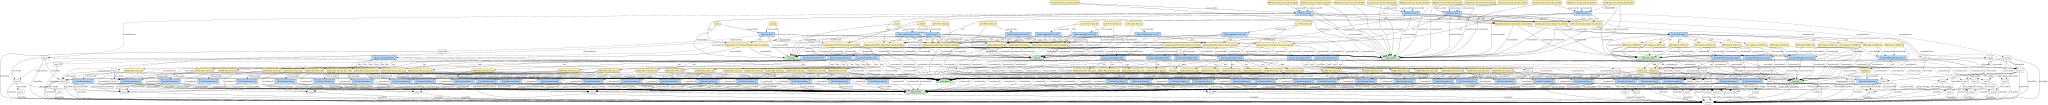

In [6]:
#plan_dot = draw_prov_only(an_roc_graph)
#display(plan_dot)

#plan_dot = draw_pplan_only(an_roc_graph)
#display(plan_dot)

fullprov_dot = draw_prov_full(an_roc_graph)
display(fullprov_dot)

In [7]:
ds_jsons = show_datasets(an_roc_graph, file_path, output_path = "",  show_only = True)

,Property,Value
0,rdf:type,<https://worldfair-project.eu/cdif/profiles/provenance/CDIF-PROV#Dataset>
1,rdf:type,schema:MediaObject
2,rdf:type,prov:Entity
3,schema:id,datasets/Sn_foil.prj_b9b199e627b0df6d.prj
4,dcterms:format,application/vnd.demeter.athena
5,dcterms:description,atsym: Nonebkg_e0: 29200edge: Nonenpts: 2094xmax: 30049.25xmin: 29000.24
6,prov:wasAttributedTo,larch_athena
7,prov:wasAttributedTo,DATA_FETCH
8,prov:wasGeneratedBy,fetch data from history
9,skos:prefLabel,Sn foil.prj


,Property,Value
0,schema:id,datasets/263934_PtSn_OCH_6.dat_5fa221e2b289fef6.tabular
1,prov:wasAttributedTo,DATA_FETCH
2,prov:wasAttributedTo,larch_athena
3,prov:wasGeneratedBy,fetch data from history
4,dcterms:description,uploaded tabular file
5,rdf:type,<https://worldfair-project.eu/cdif/profiles/provenance/CDIF-PROV#Dataset>
6,rdf:type,schema:MediaObject
7,rdf:type,prov:Entity
8,skos:prefLabel,263934_PtSn_OCH_6.dat
9,dcterms:format,text/plain


,Property,Value
0,rdf:type,<https://worldfair-project.eu/cdif/profiles/provenance/CDIF-PROV#Dataset>
1,rdf:type,schema:MediaObject
2,rdf:type,prov:Entity
3,prov:wasGeneratedBy,fetch data from history
4,skos:prefLabel,263933_PtSn_OCH_5.dat
5,dcterms:description,uploaded tabular file
6,dcterms:format,text/plain
7,schema:id,datasets/263933_PtSn_OCH_5.dat_4abf214e1e3925e6.tabular
8,prov:wasAttributedTo,larch_athena
9,prov:wasAttributedTo,DATA_FETCH


,Property,Value
0,rdf:type,<https://worldfair-project.eu/cdif/profiles/provenance/CDIF-PROV#Dataset>
1,rdf:type,schema:MediaObject
2,rdf:type,prov:Entity
3,dcterms:format,text/plain
4,skos:prefLabel,263930_PtSn_OCH_2.dat
5,prov:wasGeneratedBy,fetch data from history
6,prov:wasAttributedTo,DATA_FETCH
7,prov:wasAttributedTo,larch_athena
8,dcterms:description,uploaded tabular file
9,schema:id,datasets/263930_PtSn_OCH_2.dat_2dce3cba98f791fe.tabular


,Property,Value
0,dcterms:description,uploaded tabular file
1,rdf:type,<https://worldfair-project.eu/cdif/profiles/provenance/CDIF-PROV#Dataset>
2,rdf:type,schema:MediaObject
3,rdf:type,prov:Entity
4,dcterms:format,text/plain
5,prov:wasAttributedTo,larch_athena
6,prov:wasAttributedTo,DATA_FETCH
7,prov:wasGeneratedBy,fetch data from history
8,schema:id,datasets/263931_PtSn_OCH_3.dat_c289466c92d2c272.tabular
9,skos:prefLabel,263931_PtSn_OCH_3.dat


...

,Property,Value
0,rdf:type,<https://worldfair-project.eu/cdif/profiles/provenance/CDIF-PROV#Dataset>
1,rdf:type,schema:MediaObject
2,rdf:type,prov:Entity
3,skos:prefLabel,262880_PtSn_OCA_Abu_3.dat
4,schema:id,datasets/262880_PtSn_OCA_Abu_3.dat_c2de473dd283bcf1.tabular
5,dcterms:format,text/plain
6,prov:wasAttributedTo,larch_athena
7,prov:wasAttributedTo,DATA_FETCH
8,prov:wasGeneratedBy,fetch data from history
9,dcterms:description,uploaded tabular file


,Property,Value
0,rdf:type,prov:Entity
1,rdf:type,<https://worldfair-project.eu/cdif/profiles/provenance/CDIF-PROV#Dataset>
2,rdf:type,schema:MediaObject
3,dcterms:format,text/plain
4,prov:wasAttributedTo,larch_athena
5,prov:wasAttributedTo,DATA_FETCH
6,skos:prefLabel,262879_PtSn_OCA_Abu_2.dat
7,dcterms:description,uploaded tabular file
8,schema:id,datasets/262879_PtSn_OCA_Abu_2.dat_43ea0ddd1ab41c09.tabular
9,prov:wasGeneratedBy,fetch data from history


,Property,Value
0,skos:prefLabel,262877_PtSn_OCO_Abu_3.dat
1,prov:wasGeneratedBy,fetch data from history
2,rdf:type,prov:Entity
3,rdf:type,<https://worldfair-project.eu/cdif/profiles/provenance/CDIF-PROV#Dataset>
4,rdf:type,schema:MediaObject
5,prov:wasAttributedTo,DATA_FETCH
6,prov:wasAttributedTo,larch_athena
7,dcterms:description,uploaded tabular file
8,schema:id,datasets/262877_PtSn_OCO_Abu_3.dat_0130dc9d5e228c18.tabular
9,dcterms:format,text/plain


,Property,Value
0,prov:wasAttributedTo,DATA_FETCH
1,prov:wasAttributedTo,larch_athena
2,rdf:type,<https://worldfair-project.eu/cdif/profiles/provenance/CDIF-PROV#Dataset>
3,rdf:type,schema:MediaObject
4,rdf:type,prov:Entity
5,dcterms:description,uploaded tabular file
6,dcterms:format,text/plain
7,prov:wasGeneratedBy,fetch data from history
8,skos:prefLabel,262875_PtSn_OCO_Abu_1.dat
9,schema:id,datasets/262875_PtSn_OCO_Abu_1.dat_a2ddc3fedfe1b725.tabular


,Property,Value
0,rdf:type,<https://worldfair-project.eu/cdif/profiles/provenance/CDIF-PROV#Dataset>
1,rdf:type,schema:MediaObject
2,rdf:type,prov:Entity
3,dcterms:format,text/plain
4,skos:prefLabel,262876_PtSn_OCO_Abu_2.dat
5,dcterms:description,uploaded tabular file
6,prov:wasAttributedTo,larch_athena
7,prov:wasAttributedTo,DATA_FETCH
8,schema:id,datasets/262876_PtSn_OCO_Abu_2.dat_4788d985a9c586e4.tabular
9,prov:wasGeneratedBy,fetch data from history


In [8]:
from collections import Counter
from rdflib import RDF, Namespace

PROV = Namespace("http://www.w3.org/ns/prov#")
entities = set(an_roc_graph.subjects(RDF.type, PROV.Entity))

types = Counter()
formats = Counter()
subjects = Counter()
for e in entities:
    # entity types
    for t in an_roc_graph.objects(e, RDF.type):
        if t != PROV.Entity:
            types[str(t).split("/")[-1]] += 1

    # file formats
    for f in an_roc_graph.objects(e, DCTERMS.format):
        formats[str(f)] += 1

    # file subjects
    
    #for p, o in an_roc_graph.predicate_objects(e):
    #    print(p, o)
    #    if str(p).startswith(str(CDIF4XAS)):
    #        print(p, o)
        #print("*"*80)
        #print(e)
        #print(d)
        #subjects[str(s)] += 1

print("Total datasets:", len(entities))

print("\nTypes")
for k, v in types.most_common():
    print(f"{k}: {v}")

print("\nFormats")
for k, v in formats.most_common():
    print(f"{k}: {v}")
    
#print("\nSubjects")
#for k, v in subjects.most_common():
#   print(f"{k}: {v}")



Total datasets: 90

Types
CDIF-PROV#Dataset: 90
MediaObject: 90
CDIF-PROV#DataProduct: 18

Formats
text/plain: 42
image/png: 18
application/vnd.demeter.athena: 12
text/csv: 6
application/zip: 5
chemical/x-feff-input: 4
chemical/x-cif: 3


In [9]:
# now read it from json-lds of datasets
# assing processing levels using sweet
inv = get_roc_json_part(file_path, data_entities[3])
print(json.dumps(inv, indent=4))

{
    "@context": {
        "cdif4xas": "https://worldfair-project.eu/cdif/profiles/cdif4xas/CDIF-4-XAS#",
        "cdifprov": "https://worldfair-project.eu/cdif/profiles/provenance/CDIF-PROV#",
        "dcterms": "http://purl.org/dc/terms/",
        "ex": "http://example.org#",
        "panet": "http://purl.org/pan-science/PaNET/",
        "prov": "http://www.w3.org/ns/prov#",
        "rdfs": "http://www.w3.org/2000/01/rdf-schema#",
        "schema": "https://schema.org/",
        "skos": "http://www.w3.org/2004/02/skos/core#",
        "sostdp": "http://sweetontology.net/propOrdinal/ProcessingLevel/"
    },
    "@id": "dataset_c289466c92d2c272.jsonld",
    "@type": [
        "prov:Entity",
        "cdifprov:Dataset",
        "schema:MediaObject",
        "schema:CreativeWork"
    ],
    "cdif4xas:beamline": "B18-CORE XAS Date: Fri, 29 Jul 2016 13:44:18 BST",
    "cdif4xas:e0": "11561.2",
    "cdif4xas:edge": "L3",
    "cdif4xas:element": "Pt",
    "cdif4xas:sample_name": "PtSn_OCH",
 

In [10]:
small_graph = Graph()
#small_graph = get_panet_entities()
small_graph.parse("resources/panent_fragment.ttl")
small_graph.parse("resources/sweet-pl.ttl") 
for an_ent in data_entities:
    inv = get_roc_json_part(file_path, an_ent)
    small_graph.parse(
            data=json.dumps(inv),
            format="json-ld",publicID="/"
        )
    break
small_graph = fix_graph_root(small_graph)

In [11]:
nx_graph = rdflib_to_networkx_graph(small_graph) #load graph
print(f"Newtworkx {nx_graph} loaded successfully")

nt = Network("800px", "100%", notebook="True")
nt.from_nx(nx_graph)
nt.show_buttons(filter_=["physics"])
nt.show("nx.html")

Newtworkx Graph with 53 nodes and 43 edges loaded successfully
nx.html


In [12]:
def get_panet_entities():
    full_graph = Graph()
    full_graph.parse("resources/panet.ttl")
    reduced_lookup = Graph()
    for an_id in PANET_IDS.values():
        for a_triple in full_graph.triples((an_id, None, None)):
            reduced_lookup.add(a_triple)
    return reduced_lookup

panet_graph = get_panet_entities()
# panet_graph
# save reduced panet ontology (only used clasess)
# panet_graph.serialize(destination="resources/panent_fragment.ttl", format="ttl")

In [13]:
# This is how individual dataset JSON files are generated
for ds_entity in entities:
    ds_properties = get_dataset_properties(ds_entity, an_roc_graph)
    ds_properties = add_panet_class(ds_entity, ds_properties, an_roc_graph)
    ds_properties = add_processing_level(ds_entity, ds_properties, an_roc_graph)
    ds_properties = add_ancestor(ds_entity, ds_properties, an_roc_graph)
    ds_properties = add_cdif_metadata(ds_entity, ds_properties, an_roc_graph, file_path)
    print(ds_properties)
    break

[[rdflib.term.URIRef('http://www.w3.org/1999/02/22-rdf-syntax-ns#type'), rdflib.term.URIRef('http://www.w3.org/ns/prov#Entity')], [rdflib.term.URIRef('http://www.w3.org/1999/02/22-rdf-syntax-ns#type'), rdflib.term.URIRef('https://worldfair-project.eu/cdif/profiles/provenance/CDIF-PROV#Dataset')], [rdflib.term.URIRef('http://www.w3.org/1999/02/22-rdf-syntax-ns#type'), rdflib.term.URIRef('https://schema.org/MediaObject')], [rdflib.term.URIRef('https://schema.org/id'), rdflib.term.Literal('datasets/Athena_project_SnK_Air_data_20,_data_19,_and_data_18_dd9f988a14463c37.prj')], [rdflib.term.URIRef('http://purl.org/dc/terms/description'), rdflib.term.Literal('atsym: Sn\nbkg_e0: 29204.5\nedge: K\nnpts: 2093\nxmax: 30064.6\nxmin: 29016.1')], [rdflib.term.URIRef('http://www.w3.org/ns/prov#wasAttributedTo'), rdflib.term.URIRef('/srv/galaxy/var/shed_tools/toolshed.g2.bx.psu.edu/repos/muon-spectroscopy-computational-project/larch_lcf/larch_lcf/0.9.80+galaxy0')], [rdflib.term.URIRef('http://www.w3.o

In [14]:
for a_key in ["element", "e0", "edge", "sample_name", "sample_formula"]:
    pred = CDIF4XAS[a_key]
    print (pred)

https://worldfair-project.eu/cdif/profiles/cdif4xas/CDIF-4-XAS#element
https://worldfair-project.eu/cdif/profiles/cdif4xas/CDIF-4-XAS#e0
https://worldfair-project.eu/cdif/profiles/cdif4xas/CDIF-4-XAS#edge
https://worldfair-project.eu/cdif/profiles/cdif4xas/CDIF-4-XAS#sample_name
https://worldfair-project.eu/cdif/profiles/cdif4xas/CDIF-4-XAS#sample_formula


In [23]:
# look up graphs
panet_graph = Graph()
sweet_graph = Graph()
panet_graph.parse("resources/panent_fragment.ttl")
sweet_graph.parse("resources/sweet-pl.ttl") 

ds_data = {}
for an_ent in data_entities:
    ent_data = {}
    print(an_ent)
    small_graph = Graph()
    inv = get_roc_json_part(file_path, an_ent)
    small_graph.parse(
            data=json.dumps(inv),
            format="json-ld",publicID="/"
    )
    for s, p, o in small_graph.triples((None,SKOS.prefLabel,None)):
        d_name = o
    print(f"Dataset:     {d_name}")
    ent_data["dataset"] = d_name
    for s, p, o in small_graph.triples((None,DCTERMS.format,None)):
        file_type = o
    print(f"file type:   {file_type}")
    ent_data["file_type"] = file_type
    for s, p, o in small_graph.triples((None,SCHEMA.id,None)):
        ds_location = o
    print(f"Location:    {ds_location}")
    ent_data["location"] = ds_location
    e_symbol = ""
    for s, p, o in small_graph.triples((None,CDIF4XAS.element,None)):
        e_symbol = o
    print(f"Element:     {e_symbol}")
    ent_data["element"] = e_symbol
    a_edge = ""
    for s, p, o in small_graph.triples((None,CDIF4XAS.edge,None)):
        a_edge = o
    print(f"Edge:        {a_edge}")
    ent_data["edge"] = a_edge
    e_zero = ""
    for s, p, o in small_graph.triples((None,CDIF4XAS.e0,None)):
        e_zero = o
    print(f"E0:          {e_zero}")
    ent_data["e0"] = e_zero
    for s, p, o in small_graph.triples((None,DCTERMS.subject,None)):
        if str(PANET) in str(o):
            print ("panet ", o)
            for panet_desc in panet_graph.objects(o, SKOS.altLabel):
                print(panet_desc)
                ent_data["data_type"] = panet_desc
        else:
            print ("level ", o)
            for level_name in sweet_graph.objects(o, SKOS.prefLabel):
                print(level_name)
                ent_data["proc_level"] = level_name
    ds_data[an_ent] = ent_data

provenance/dataset_b9b199e627b0df6d.jsonld
Dataset:     Sn foil.prj
file type:   application/vnd.demeter.athena
Location:    datasets/Sn_foil.prj_b9b199e627b0df6d.prj
Element:     Sn
Edge:        K
E0:          29200.0
panet  http://purl.org/pan-science/PaNET/PaNET01196
XAS
level  http://sweetontology.net/propOrdinal/ProcessingLevel/Level1
Processed
provenance/dataset_c1b1e33af4bbfb98.jsonld
Dataset:     263929_PtSn_OCH_1.dat
file type:   text/plain
Location:    datasets/263929_PtSn_OCH_1.dat_c1b1e33af4bbfb98.tabular
Element:     Pt
Edge:        L3
E0:          11561.2
panet  http://purl.org/pan-science/PaNET/PaNET01196
XAS
level  http://example.org#Level0
Raw
provenance/dataset_2dce3cba98f791fe.jsonld
Dataset:     263930_PtSn_OCH_2.dat
file type:   text/plain
Location:    datasets/263930_PtSn_OCH_2.dat_2dce3cba98f791fe.tabular
Element:     Pt
Edge:        L3
E0:          11561.2
panet  http://purl.org/pan-science/PaNET/PaNET01196
XAS
level  http://example.org#Level0
Raw
provenance/dat

In [22]:
len(ds_data)

90